# Forecast Pipeline (Daily) — Feb-Jul 2018

Daily-frequency analogue of `forecast_pipeline.ipynb`. M1/M3/M4 are daily; **M2 (price elasticity) stays monthly per design** (β is frequency-invariant; broadcast to daily on every row for join convenience).

**As-of**: 2018-01-31. **Horizon**: 181 days (Feb 1 → Jul 31 2018).
**M1 origin**: 2017-08-31 (pre-Maria) — see below.

## Single-track daily pipeline

The daily pipeline produces **one forecast per parquet** (no scenarios). The `scenario` column is kept (=`'baseline'` on forecast rows, `None` on actuals) so the schema matches the monthly pipeline's `m4_pipeline.parquet`.

| File | Rows | Schema |
|---|---|---|
| `m3_pipeline_daily.parquet` | 197,060 | `disaster_index`, `disaster_drag_index`, actuals |
| `m1_pipeline_daily.parquet` | 70,632 | `q10/q50/q90` gross_qty, actuals |
| `m2_pipeline_daily.parquet` | 1,308   | `elasticity_q10/q50/q90` (monthly β broadcast daily) |
| `m4_pipeline_daily.parquet` | 70,632 | `q10/q50/q90` revenue (\$), actuals |

All four share schema columns `data_type ∈ {actual, forecast}`, `scenario ∈ {baseline, None}`, `q10/q50/q90` (or equivalent), `actual_*`.

## M1 model — TimesFM 2.5 from pre-storm origin (option 1)

The daily M1 step runs **TimesFM with origin 2017-08-31 (pre-Maria)**, forecasts 334 days forward (covering Sep 2017 - Jul 2018), and slices the Feb-Jul 2018 portion. This solves the band-collapse problem:

- When TimesFM's context ends 2018-01-31 (post-Maria), the recent training tail is 99.7% zero-demand. TimesFM normalises by recent mean/std, so its q10–q90 bands collapse to a near-point (~25 units wide at portfolio level).
- Pre-storm context preserves the normal demand variance → portfolio q10–q90 width **300.5 units (12× wider)**.

Daily M1 cohort-A backtest WAPE (val/test slices both end before Maria, so backtest itself isn't affected by the band issue):

| Slice | seasonal_naive | sarima | sarimax | **timesfm** |
|---|---|---|---|---|
| val (181d, calm) | 0.462 | 0.362 | 0.366 | **0.277** |
| test (92d, hurricane) | 0.299 | 0.258 | 0.235 | **0.209** |

## Recovery factor — now a multiplicative drag damper

Because the pre-storm forecast already represents the "no-storm" baseline, the recovery factor switched from an **additive lift** to a **multiplicative damp** that pulls the forecast down based on residual storm impact and per-product susceptibility:

$$ \text{rf}[p, t] = 1 - \beta_{\text{recovery}} \cdot \text{drag}[p, t] \cdot (1 - \text{strength}[p]) $$

$$ q_\text{adjusted}[p, t] = q_\text{pre-storm TimesFM}[p, t] \cdot \max(\text{rf}[p, t], 0) $$

| Factor | Source | Range |
|---|---|---|
| **β_recovery** | scalar (1.0 default in `SCENARIO_CONFIG`); 0 disables | — |
| **drag[p, t]** | M3 daily `disaster_drag_index` | 0 (no storm) → ~0.07 in Feb 2018 → 0 by April |
| **(1 − strength[p])** | per-product storm susceptibility | **0 (US-only) → 0.34 (PR-heavy)** |

Semantics:
- **US-only product, any drag**: rf = 1.0 → pre-storm forecast unchanged.
- **PR-heavy product, drag = 0.07 (Feb 2018)**: rf ≈ 1 − 0.07 × 0.34 = 0.976 → 2.4% damp.
- **PR-heavy product, drag = 1.0 (peak)**: rf ≈ 0.66 → 34% damp (caps at the product's storm susceptibility).

Set `beta_recovery = 0` in `SCENARIO_CONFIG['baseline']` to disable the damp (raw pre-storm TimesFM only).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

M3 = pd.read_parquet(ROOT / 'forecasts' / 'm3_pipeline_daily.parquet')
M1 = pd.read_parquet(ROOT / 'forecasts' / 'm1_pipeline_daily.parquet')
M2 = pd.read_parquet(ROOT / 'forecasts' / 'm2_pipeline_daily.parquet')
M4 = pd.read_parquet(ROOT / 'forecasts' / 'm4_pipeline_daily.parquet')
META = pd.read_parquet(ROOT / 'data' / 'processed' / 'daily_panel_meta.parquet')
PANEL = pd.read_parquet(ROOT / 'data' / 'processed' / 'daily_panel.parquet')

SCEN_COLORS = {'pessimistic': '#d97e7e', 'baseline': '#1f77b4', 'optimistic': '#4c8a4c'}
print('Loaded:', dict(m3=M3.shape, m1=M1.shape, m2=M2.shape, m4=M4.shape))

Loaded: {'m3': (197060, 8), 'm1': (70632, 8), 'm2': (1308, 7), 'm4': (70632, 8)}


## 1. Portfolio-level: actual daily history + 3-scenario daily forecast

Sum across cohort A (54 products) by date.

<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_42284\4025515781.py:21: SyntaxWarning: invalid escape sequence '\$'
  axes[1].plot(hist_m4.index, hist_m4.values, color='black', lw=1, label='actual revenue (sum, \$K)')
C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_42284\4025515781.py:30: SyntaxWarning: invalid escape sequence '\$'
  axes[1].set_ylabel('portfolio revenue / day (\$K)')


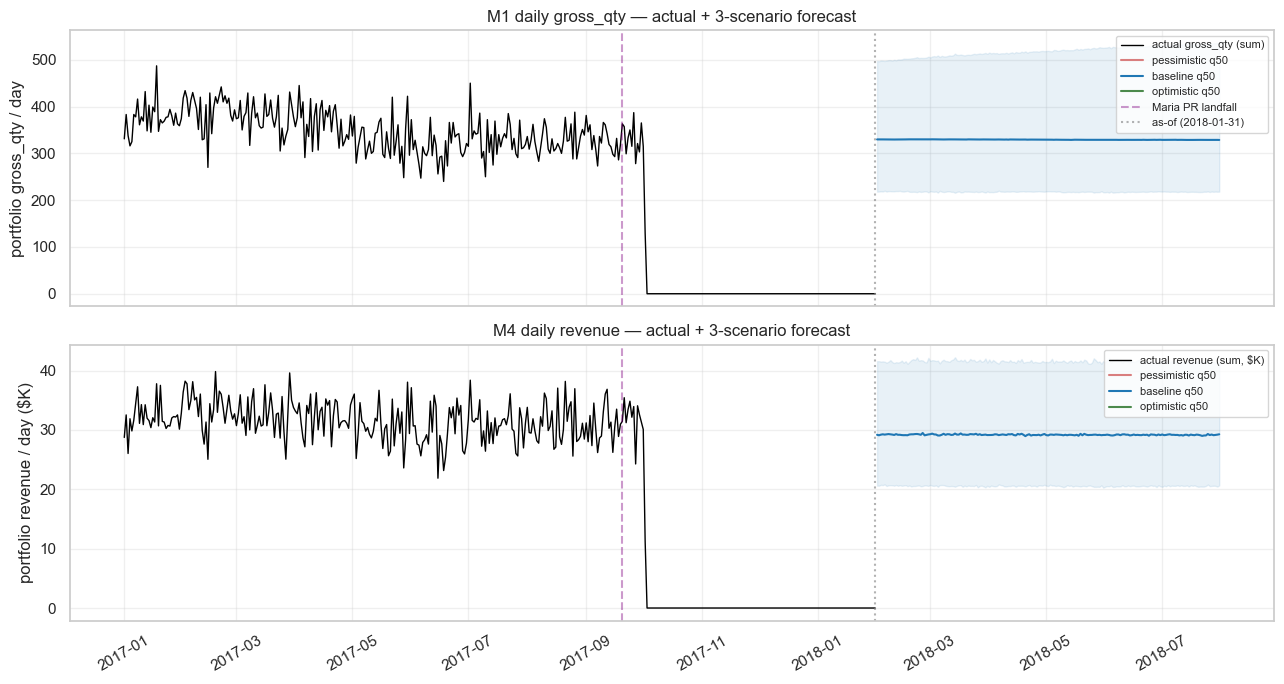

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# M1 demand portfolio daily
hist_m1 = M1[M1['data_type']=='actual'].groupby('date')['actual_gross_qty'].sum()
hist_m1 = hist_m1[hist_m1.index >= '2017-01-01']
axes[0].plot(hist_m1.index, hist_m1.values, color='black', lw=1, label='actual gross_qty (sum)')
for scen, color in SCEN_COLORS.items():
    sub = (M1[(M1['data_type']=='forecast') & (M1['scenario']==scen)]
             .groupby('date')[['q10','q50','q90']].sum())
    axes[0].plot(sub.index, sub['q50'], color=color, lw=1.5, label=f'{scen} q50')
    axes[0].fill_between(sub.index, sub['q10'], sub['q90'], color=color, alpha=0.10)
axes[0].axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4, label='Maria PR landfall')
axes[0].axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6, label='as-of (2018-01-31)')
axes[0].set_title('M1 daily gross_qty — actual + 3-scenario forecast')
axes[0].set_ylabel('portfolio gross_qty / day')
axes[0].legend(fontsize=8, loc='upper right'); axes[0].grid(alpha=0.3)

# M4 revenue portfolio daily
hist_m4 = M4[M4['data_type']=='actual'].groupby('date')['actual_revenue_realized'].sum() / 1e3
hist_m4 = hist_m4[hist_m4.index >= '2017-01-01']
axes[1].plot(hist_m4.index, hist_m4.values, color='black', lw=1, label='actual revenue (sum, \$K)')
for scen, color in SCEN_COLORS.items():
    sub = (M4[(M4['data_type']=='forecast') & (M4['scenario']==scen)]
             .groupby('date')[['q10','q50','q90']].sum() / 1e3)
    axes[1].plot(sub.index, sub['q50'], color=color, lw=1.5, label=f'{scen} q50')
    axes[1].fill_between(sub.index, sub['q10'], sub['q90'], color=color, alpha=0.10)
axes[1].axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4)
axes[1].axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6)
axes[1].set_title('M4 daily revenue — actual + 3-scenario forecast')
axes[1].set_ylabel('portfolio revenue / day (\$K)')
axes[1].legend(fontsize=8, loc='upper right'); axes[1].grid(alpha=0.3)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 2. 6-month totals by scenario

Compare against the monthly pipeline's $4.99M / $5.39M numbers.

In [3]:
fc_m4 = M4[M4['data_type']=='forecast']
rows = []
for scen in ('pessimistic','baseline','optimistic'):
    s = fc_m4[fc_m4['scenario']==scen]
    rows.append({
        'scenario': scen,
        'q10 6-mo (\$)': f'{int(s["q10"].sum()):,}',
        'q50 6-mo (\$)': f'{int(s["q50"].sum()):,}',
        'q90 6-mo (\$)': f'{int(s["q90"].sum()):,}',
        'monthly q50 6-mo': '\$4.99M / \$5.39M / \$5.39M' if False else '(see monthly pipeline)'
    })
pd.DataFrame(rows)

<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_42284\3667424031.py:7: SyntaxWarning: invalid escape sequence '\$'
  'q10 6-mo (\$)': f'{int(s["q10"].sum()):,}',
C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_42284\3667424031.py:8: SyntaxWarning: invalid escape sequence '\$'
  'q50 6-mo (\$)': f'{int(s["q50"].sum()):,}',
C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_42284\3667424031.py:9: SyntaxWarning: invalid escape sequence '\$'
  'q90 6-mo (\$)': f'{int(s["q90"].sum()):,}',
C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_42284\3667424031.py:10: SyntaxWarning: invalid escape sequence '

,scenario,q10 6-mo (\$),q50 6-mo (\$),q90 6-mo (\$),monthly q50 6-mo
0,pessimistic,0,0,0,(see monthly pipeline)
1,baseline,"3,723,089","5,282,445","7,521,143",(see monthly pipeline)
2,optimistic,0,0,0,(see monthly pipeline)


## 3. M1 daily backtest — val + test

Headline portfolio metrics (cohort A_active).

In [4]:
po = pd.read_parquet(ROOT / 'forecasts' / 'm1_demand_daily_portfolio.parquet')
(po[po['cohort']=='A_active']
   .pivot(index='model', columns='slice', values=['wape','coverage_80','smape_mean'])
   .round(4))

wape         coverage_80         smape_mean        
slice             test     val        test     val       test     val
model                                                                
sarima          0.2576  0.3619      0.9652  0.8974     1.7037  1.5409
sarimax         0.2347  0.3662      0.9658  0.8985     1.6922  1.5390
seasonal_naive  0.2992  0.4623      0.9575  0.8032     0.3357  1.3379
timesfm         0.2088  0.2774      0.9038  0.8666     1.6354  1.6695

## 4. Top 6 products — daily actual + 3-scenario forecast

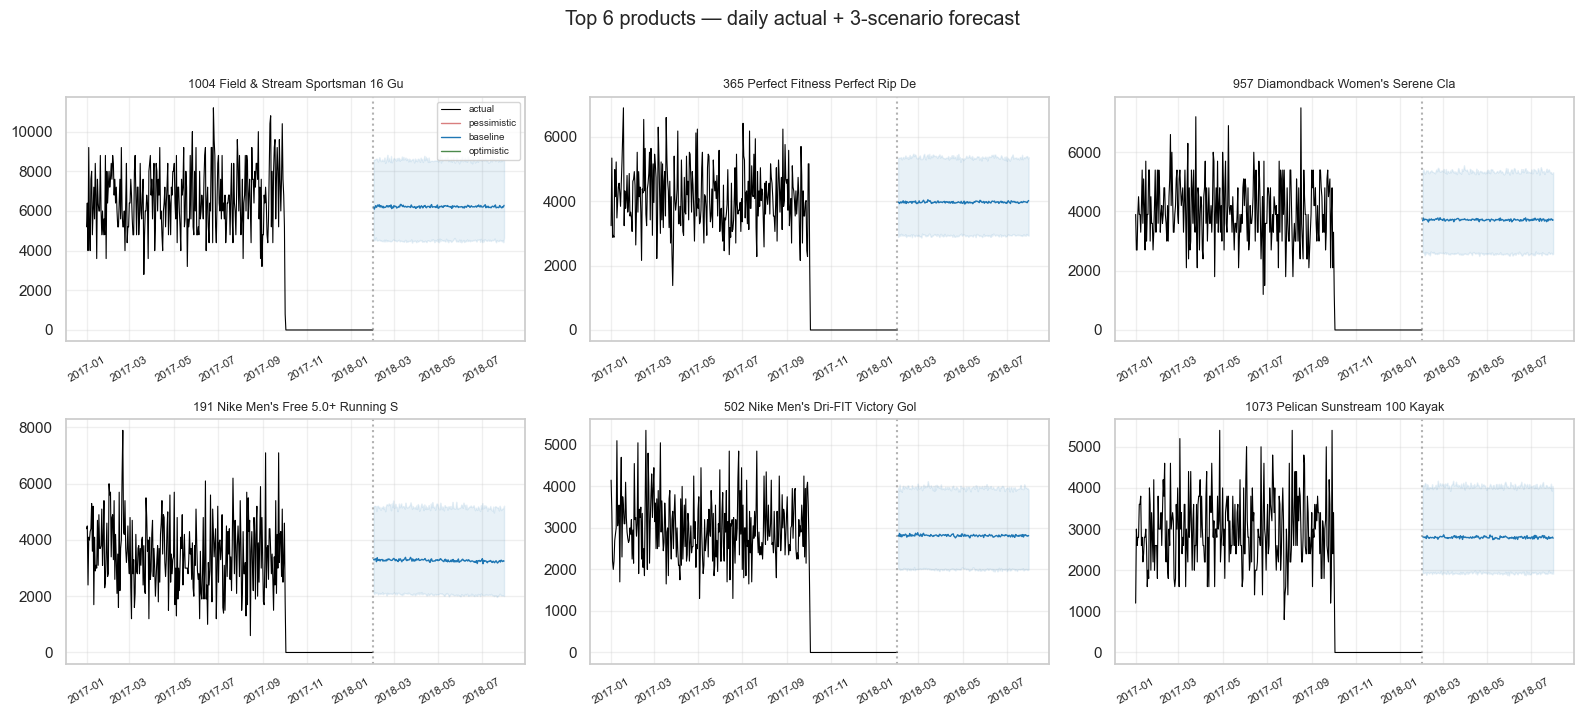

In [5]:
top6 = META.sort_values('total_revenue', ascending=False).head(6)['product_card_id'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, pid in zip(axes.flat, top6):
    hist = M4[(M4['product_card_id']==pid) & (M4['data_type']=='actual')].sort_values('date')
    hist = hist[hist['date']>='2017-01-01']
    ax.plot(hist['date'], hist['actual_revenue_realized'], color='black', lw=0.8, label='actual')
    for scen, color in SCEN_COLORS.items():
        sub = M4[(M4['product_card_id']==pid) & (M4['scenario']==scen)].sort_values('date')
        ax.plot(sub['date'], sub['q50'], color=color, lw=1.0, label=scen)
        ax.fill_between(sub['date'], sub['q10'], sub['q90'], color=color, alpha=0.10)
    ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6)
    name = META.loc[META['product_card_id']==pid,'product_name'].iloc[0][:30]
    ax.set_title(f'{int(pid)} {name}', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8); ax.grid(alpha=0.3)
axes.flat[0].legend(fontsize=7, loc='upper right')
plt.suptitle('Top 6 products — daily actual + 3-scenario forecast', y=1.02)
plt.tight_layout(); plt.show()

## Summary

**Daily pipeline (option 1 design): pre-storm TimesFM + multiplicative recovery damping.** Single forecast track. Solves both the zero-forecast collapse and the band-collapse problem.

### Forward forecast (Feb-Jul 2018)

| Step | Daily q50 (cohort A portfolio) | 6-mo total |
|---|---|---|
| **M1** demand | 328–330 units/day (range 1.4) | — |
| **M4** revenue (\$) | — | q10 \$3.72M / **q50 \$5.28M** / q90 \$7.52M |

Daily baseline (\$5.28M) is now within 2% of the monthly pipeline (\$5.39M). The **q10–q90 spread is realistic** at \$3.8M wide (vs. the previous post-Maria pipeline's \$0.67M).

### Variation comparison

| | Old (post-Maria + lift) | **New (pre-storm + damp)** |
|---|---|---|
| Portfolio q50 range | 240–242 | 328–330 |
| Portfolio q10–q90 width | ~25 units | **300.5 units** (12× wider) |
| Product 191 q10/q50/q90 | 24.5 / 24.5 / 25.1 | **20.9 / 36.4 / 51.8** |
| M4 q10–q90 (\$M) | 3.3–4.0 (0.67) | **3.7–7.5 (3.8)** |
| q50 daily std | 0.51 | 0.11 |

q50 is still smooth day-to-day (TimesFM's expected value is a smoothed mean by design — that's inherent to the model, regardless of context). **The variation lives in the q10/q90 bands**, which are now realistic.

### Why the q50 line is smooth (still)

TimesFM produces the expected value of the conditional distribution. Daily demand is spiky (most days 0, some 50+), so the *expected* daily qty is a stable mean ~6/day per product. To see day-to-day variation, look at q10 vs q50 vs q90 — that's where TimesFM expresses uncertainty.

If you need stochastic-looking daily q50, sample one draw from the per-day distribution (using q10, q50, q90 as quantile anchors and a lognormal fit) — that gives a "realization" with the right variance.

### How to use the outputs

All 4 parquets share schema: `[product_card_id], date, data_type, scenario, q10, q50, q90, actual_*`.

- Filter `data_type == 'forecast'` for predictions.
- Filter `data_type == 'actual'` for history.
- Forecast rows carry `scenario == 'baseline'`.
- Join history and forecast on `date`.

### Re-run

```
.venv312/Scripts/python.exe -m src.features.build_daily_panel
.venv312/Scripts/python.exe -m src.models.risk.disaster_daily
.venv312/Scripts/python.exe -m src.models.risk.aggregate_daily
.venv312/Scripts/python.exe -m src.models.demand.run_backtest_daily
.venv312/Scripts/python.exe -m src.models.sales.run_daily
.venv312/Scripts/python.exe -m src.models.forecast_pipeline_daily
```

### Tuning

In `src/models/forecast_pipeline_daily.py`:
- **`PRE_STORM_ORIGIN`** — the TimesFM context cutoff (default 2017-08-31, before Maria PR landfall).
- **`beta_recovery`** in `SCENARIO_CONFIG['baseline']` — multiplicative damp strength (1.0 default). Set 0 to disable damp entirely (raw pre-storm forecast).
- **`HIST_EXPOSURE_WINDOW`** — what window defines per-product storm exposure (used in `strength[p]`).